In [185]:
import mplfinance as mpl
import yfinance as yf
import datetime as dt
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [186]:
tickers = ["JPM",'XLF']

start_date = dt.date(2022,1,1)

data = yf.download(tickers, start= start_date, period="1y", interval="1d", group_by='ticker')

[*********************100%***********************]  2 of 2 completed


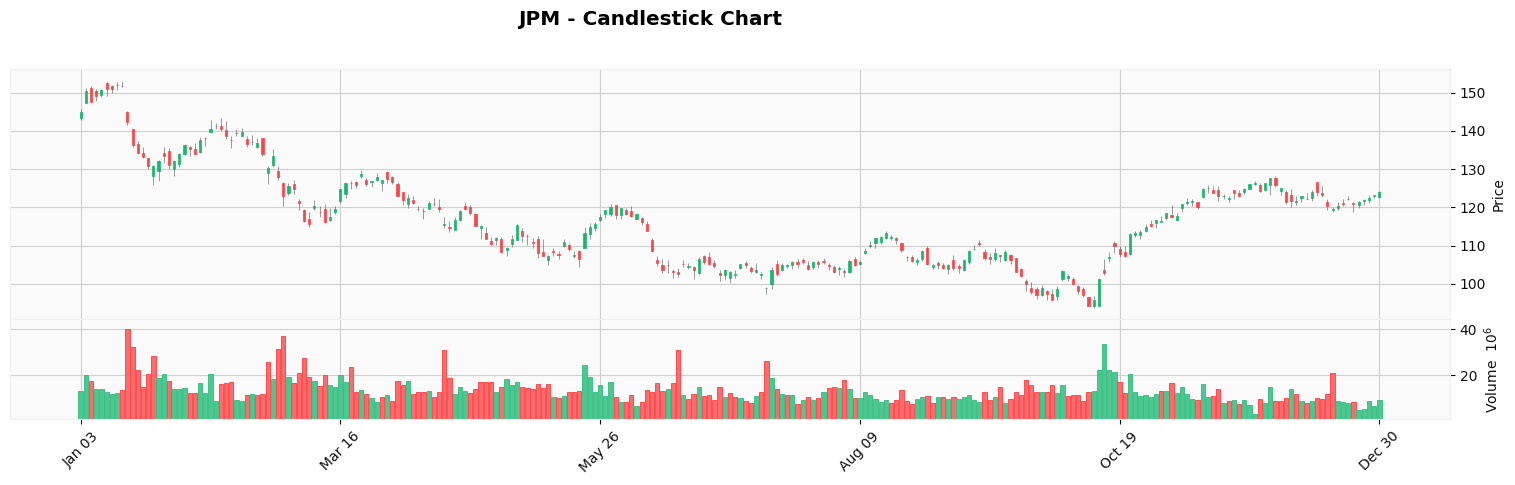

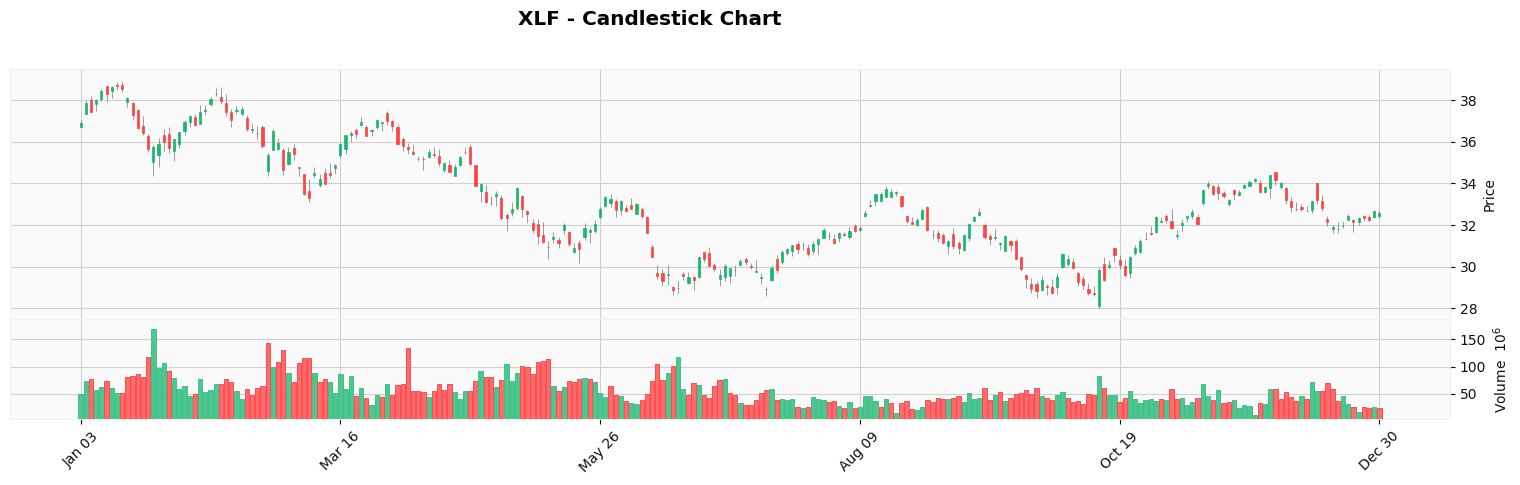

In [187]:
JPM_df = data[tickers[0]]
XLF_df = data[tickers[1]]

mpl.plot(
    data=JPM_df,
    type="candle",
    style="yahoo",
    figsize=(20, 5),
    volume=True,
    title=f"{tickers[0]} - Candlestick Chart"
    )

mpl.plot(
    data=XLF_df,
    type="candle",
    style="yahoo",
    figsize=(20, 5),
    volume=True,
    title=f"{tickers[1]} - Candlestick Chart"
    )

In [188]:
JPM = yf.Ticker(tickers[0])
XLF = yf.Ticker(tickers[1])

print(f"Ticker name {tickers[0]}: {JPM.info['longName']}")
print(f"Ticker name {tickers[1]}: {XLF.info['longName']}")

Ticker name JPM: JPMorgan Chase & Co.
Ticker name XLF: State Street Financial Select Sector SPDR ETF


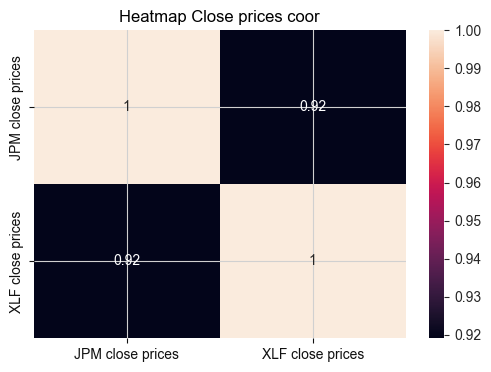

In [189]:
coor = np.corrcoef(JPM_df['Close'],XLF_df['Close'])

plt.figure(figsize=(6, 4))
plt.title("Heatmap Close prices coor")
sns.set_style("white")
heatmap = sns.heatmap(
    data = coor,
    annot = True,
    cmap="rocket",
    fmt=".2g"
    )
heatmap.set_xticklabels([f'{tickers[0]} close prices', f'{tickers[1]} close prices'])
heatmap.set_yticklabels([f'{tickers[0]} close prices', f'{tickers[1]} close prices'])
plt.show()

In [190]:
JPM_return = JPM_df["Close"].pct_change().dropna()
XLF_return = XLF_df["Close"].pct_change().dropna()

covariance_matrix = np.cov(JPM_return, XLF_return)
covariance = covariance_matrix[0, 1]
product_variance = np.var(XLF_return, ddof=1) 
beta = (covariance / product_variance).item()
beta

1.0850687050760845

In [ ]:
df_reshaped_JPM = JPM_return.values.reshape(-1, 1)
df_reshaped_XLF = XLF_return.values.reshape(-1, 1)

reg = LinearRegression().fit(df_reshaped_XLF,df_reshaped_JPM)

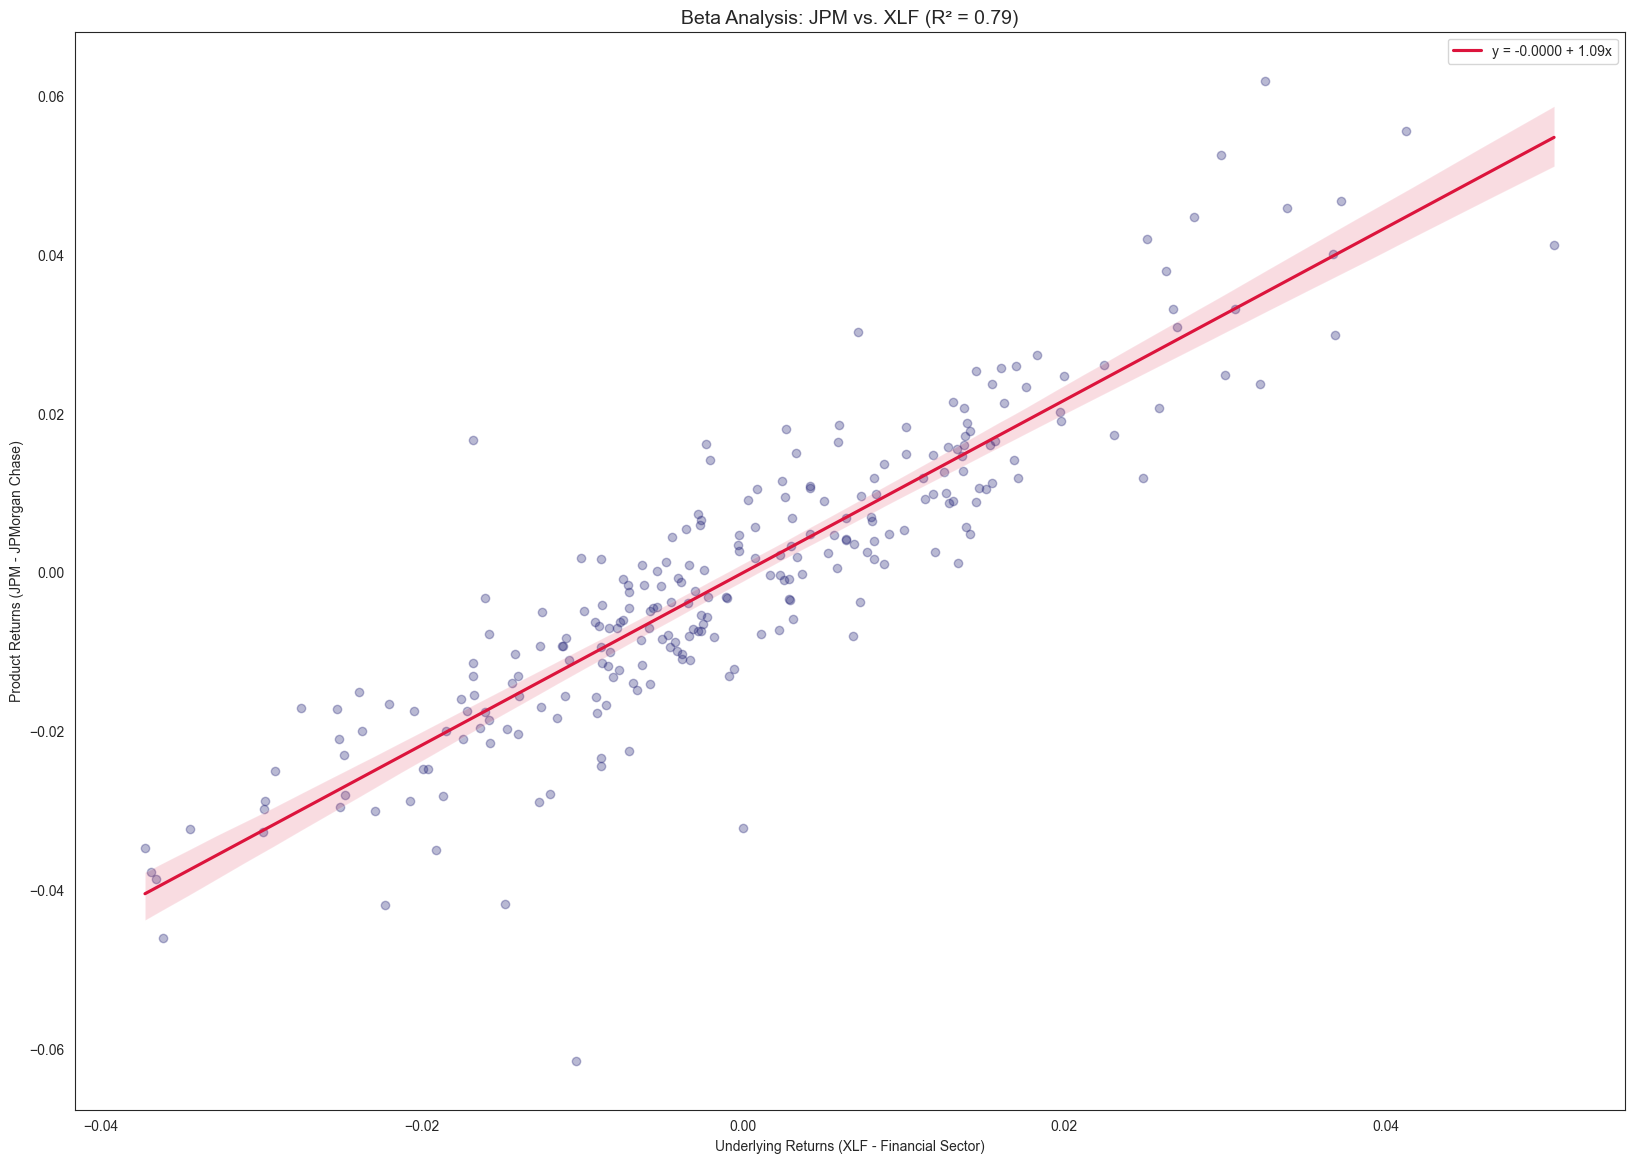

In [ ]:
beta = reg.coef_.item()
alpha = reg.intercept_[0]
r_squared = reg.score(df_reshaped_XLF, df_reshaped_JPM)

plt.figure(figsize=(20,14))
sns.regplot(x=XLF_return, 
            y=JPM_return, 
            scatter_kws={'alpha': 0.3, 'color': 'midnightblue'}, 
            line_kws={'color': 'crimson', 'label': f'y = {alpha:.4f} + {beta:.2f}x'})

plt.title(f"Beta Analysis: JPM vs. XLF (R² = {r_squared:.2f})", fontsize=14)
plt.xlabel("Underlying Returns (XLF - Financial Sector)")
plt.ylabel("Product Returns (JPM - JPMorgan Chase)")
plt.legend()
plt.show()